### Imports and Configuration

In [1]:
import pandas as pd

from pipeline_utils import make_case3_paths

paths = make_case3_paths()
nest_vnn_dir = paths["project"] / "pretrained_models" / "nest_vnn"
results_root = nest_vnn_dir / "results"

FIGURES_DIR = paths["figures"]
FIGURES_SUPP_DIR = paths["figures_supp"]
TABLES_DIR = paths["tables"]

N_FOLDS = 5

# Per-cohort: where the 5-fold predictions live, the row order (cell2ind.txt) they
# follow, and the model metadata table (+ join key) to merge them back onto.
COHORTS = {
    "McGill_cisplatin": {
        "cell2ind": paths["proc"] / "McGill_nest_input" / "cell2ind.txt",
        "meta": paths["proc"] / "McGill_cisplatin_models.tsv",
        "meta_key": "model_id",
    },
    "UHN_carboplatin_complete": {
        "cell2ind": paths["proc"] / "UHN_nest_input" / "complete_cohort" / "cell2ind.txt",
        "meta": paths["proc"] / "UHN_carboplatin_models.tsv",
        "meta_key": "model.id",
    },
    "UHN_carboplatin_strict": {
        "cell2ind": paths["proc"] / "UHN_nest_input" / "strict_cohort" / "cell2ind.txt",
        "meta": paths["proc"] / "UHN_carboplatin_models.tsv",
        "meta_key": "model.id",
    },
}

### Aggregate the 5-fold ensemble predictions per cohort and join back to model metadata

In [2]:
def aggregate_nest_vnn_folds(cohort_name, cfg, n_folds=N_FOLDS):
    """Average the per-fold predict.py outputs and join them onto the cohort's model metadata."""
    result_dir = results_root / cohort_name
    meta_key = cfg["meta_key"]

    # fold*.txt row order follows cell2ind.txt (index, model id), not necessarily sorted
    order_df = pd.read_csv(cfg["cell2ind"], sep="\t", header=None, names=["index", meta_key])
    order_df = order_df.sort_values("index")

    fold_cols = {}
    for i in range(1, n_folds + 1):
        fold_cols[f"fold{i}"] = pd.read_csv(result_dir / f"fold{i}.txt", header=None)[0].to_numpy()

    pred_df = pd.DataFrame(fold_cols)
    pred_df.insert(0, meta_key, order_df[meta_key].to_numpy())
    pred_df["average"] = pred_df[[f"fold{i}" for i in range(1, n_folds + 1)]].mean(axis=1)

    meta_df = pd.read_csv(cfg["meta"], sep="\t")
    merged = pred_df.merge(meta_df, on=meta_key, how="left")

    out_path = paths["proc"] / f"{cohort_name}_nest_vnn_predictions.csv"
    merged.to_csv(out_path, index=False)
    print(f"{cohort_name}: n={len(merged)}, saved -> {out_path}")
    return merged

In [3]:
predictions = {name: aggregate_nest_vnn_folds(name, cfg) for name, cfg in COHORTS.items()}

McGill_cisplatin: n=29, saved -> /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/3_carboplatin/McGill_cisplatin_nest_vnn_predictions.csv
UHN_carboplatin_complete: n=68, saved -> /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/3_carboplatin/UHN_carboplatin_complete_nest_vnn_predictions.csv
UHN_carboplatin_strict: n=36, saved -> /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/3_carboplatin/UHN_carboplatin_strict_nest_vnn_predictions.csv


In [4]:
predictions["McGill_cisplatin"].head()

,model_id,fold1,fold2,fold3,fold4,fold5,average,batch.name,auc.control,auc.treatment,abc,TGI,drug,omics_id,n_replicates,slope.control,slope.treatment,angle,mRECIST
0,GCRC1715,0.86117,0.80786,0.79264,0.75843,0.74214,0.792448,GCRC1715.Cisplatin,2219.812500,2596.00000,-376.187500,-1.016667,Cisplatin,SA1029X2_14L,1,54.271639,-68.002347,122.273986,PR
1,GCRC1735,0.83152,0.76734,0.72860,0.73806,0.71399,0.755902,GCRC1735.Cisplatin,22322.492188,13846.34375,8476.148438,29.519122,Cisplatin,SA920X2_23R,1,89.406136,88.952858,0.453277,PD
2,GCRC1738,0.77711,0.61519,0.60759,0.68399,0.60228,0.657232,GCRC1738.Cisplatin,13768.718750,2941.40625,10827.312500,29.268293,Cisplatin,SA1030X2_17L,1,88.040696,-12.378498,100.419193,SD
3,GCRC1828,0.76438,0.67729,0.67034,0.64899,0.63830,0.679860,GCRC1828.Cisplatin,2723.031250,1417.81250,1305.218750,-56.000000,Cisplatin,SA1027X1_1L,1,64.083367,-62.804243,126.887610,SD
4,GCRC1834,0.86626,0.82506,0.83427,0.78636,0.78464,0.819318,GCRC1834.Cisplatin,2302.968750,734.61000,1568.358750,7.558824,Cisplatin,SA1028X3_3L,1,66.246594,-44.782399,111.028992,PR


### AUROC at a fixed absolute threshold (slope.treatment = 0deg: growth vs. regression), with bootstrap CI

In [5]:
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve


def bootstrap_auroc(y_true, y_score, n_boot=2000, seed=0):
    """Point-estimate AUROC plus the full bootstrap distribution (resampling models with replacement)."""
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    n = len(y_true)

    point = roc_auc_score(y_true, y_score)

    boot_aucs = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        yt = y_true[idx]
        if yt.min() == yt.max():
            continue  # degenerate resample (single class), skip
        boot_aucs.append(roc_auc_score(yt, y_score[idx]))

    lo, hi = np.percentile(boot_aucs, [2.5, 97.5])
    return point, lo, hi, np.array(boot_aucs)


auroc_results = {}
print("AUROC: predicted response (5-fold average) vs. sensitive (slope.treatment < 0) / resistant (>= 0)")
for name, df in predictions.items():
    sub = df.dropna(subset=["average", "slope.treatment"])
    target = (sub["slope.treatment"] < 0).astype(int)  # 1 = sensitive (net tumor regression)

    point, lo, hi, boot_aucs = bootstrap_auroc(target, sub["average"])
    auroc_results[name] = {
        "auroc": point, "ci_lo": lo, "ci_hi": hi, "n": len(sub),
        "n_sensitive": int(target.sum()), "boot_aucs": boot_aucs,
    }

    print(f"  {name}: n={len(sub)} (sensitive={target.sum()}, resistant={len(sub) - target.sum()}), "
          f"AUROC={point:.3f} [95% CI {lo:.3f}-{hi:.3f}] (n_boot={len(boot_aucs)})")

AUROC: predicted response (5-fold average) vs. sensitive (slope.treatment < 0) / resistant (>= 0)


  McGill_cisplatin: n=29 (sensitive=16, resistant=13), AUROC=0.486 [95% CI 0.260-0.697] (n_boot=2000)


  UHN_carboplatin_complete: n=68 (sensitive=12, resistant=56), AUROC=0.577 [95% CI 0.371-0.771] (n_boot=2000)


  UHN_carboplatin_strict: n=36 (sensitive=5, resistant=31), AUROC=0.839 [95% CI 0.626-0.984] (n_boot=1994)


Saved: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/figures_tables/figures_supp/supp_figure3f_roc_curves.png


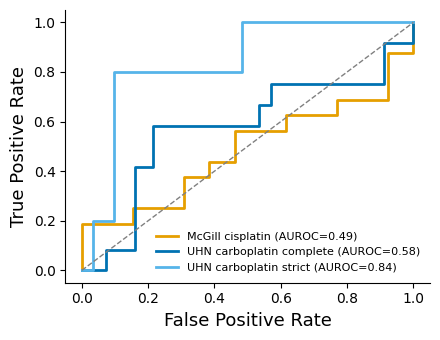

In [6]:
import matplotlib.pyplot as plt

COHORT_PLOT_COLORS = {
    "McGill_cisplatin": "#E69F00",
    "UHN_carboplatin_complete": "#0072B2",
    "UHN_carboplatin_strict": "#56B4E9",
}

fig, ax = plt.subplots(figsize=(4.5, 3.5))

for name, df in predictions.items():
    sub = df.dropna(subset=["average", "slope.treatment"])
    target = (sub["slope.treatment"] < 0).astype(int)
    fpr, tpr, _ = roc_curve(target, sub["average"])
    r = auroc_results[name]
    ax.plot(fpr, tpr, color=COHORT_PLOT_COLORS[name], lw=2,
            label=f"{name.replace('_', ' ')} (AUROC={r['auroc']:.2f})")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("False Positive Rate", fontsize = 13)
ax.set_ylabel("True Positive Rate", fontsize = 13)
ax.legend(frameon=False, fontsize=8, loc="lower right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
out_path = FIGURES_SUPP_DIR / "supp_figure3f_roc_curves.png"
plt.savefig(out_path, dpi=300)
plt.savefig(out_path.with_suffix(".pdf"))
print("Saved:", out_path)
plt.show()

### Model performance summary table

In [7]:
import pandas as pd

# Primary model-performance summary (bootstrap AUROC) per cohort, plus a two-sided bootstrap
# p-value against chance (0.5) computed from the same bootstrap resamples used for the 95% CI
# above -- same underlying bootstrap, not a new test -- and in the same table format as the
# case study 1 performance summary.
summary_rows = []
for name in predictions:
    r = auroc_results[name]
    boot = r["boot_aucs"]
    p_boot = min(1.0, 2 * min((boot <= 0.5).mean(), (boot >= 0.5).mean()))
    summary_rows.append({
        "Cohort": name.replace("_", " "),
        "n": r["n"],
        "n_sensitive": r["n_sensitive"],
        "n_resistant": r["n"] - r["n_sensitive"],
        "AUROC": r["auroc"],
        "AUROC_ci_lo": r["ci_lo"],
        "AUROC_ci_hi": r["ci_hi"],
        "AUROC_bootstrap_p_vs_chance": p_boot,
    })

performance_summary = pd.DataFrame(summary_rows)
performance_summary_file = TABLES_DIR / "table5_case3_nestvnn_model_performance.csv"
performance_summary.to_csv(performance_summary_file, index=False)

print(f"Saved model performance summary (bootstrap AUROC with 95% CI and two-sided bootstrap "
      f"p-value vs. chance = 0.5) to {performance_summary_file}")
performance_summary

Saved model performance summary (bootstrap AUROC with 95% CI and two-sided bootstrap p-value vs. chance = 0.5) to /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/figures_tables/tables/table5_case3_nestvnn_model_performance.csv


,Cohort,n,n_sensitive,n_resistant,AUROC,AUROC_ci_lo,AUROC_ci_hi,AUROC_bootstrap_p_vs_chance
0,McGill cisplatin,29,16,13,0.485577,0.259572,0.696973,0.916000
1,UHN carboplatin complete,68,12,56,0.577381,0.370968,0.771093,0.480000
2,UHN carboplatin strict,36,5,31,0.838710,0.626042,0.984375,0.012036


### Robustness check: AUROC across bottom-percentile "sensitive" cutoffs (10-90%, per cohort)

In [8]:
PERCENTILES = list(range(10, 100, 10))


def auroc_percentile_sweep(df, percentiles=PERCENTILES, n_boot=1000, seed=0):
    """AUROC (+ bootstrap CI and two-sided bootstrap p-value vs. chance) when 'sensitive' =
    bottom X% of slope.treatment, per cohort. Same bootstrap-resample p-value convention as
    the primary AUROC result and the model-performance summary table above -- reuses the same
    bootstrap resamples already drawn for the CI rather than a separate test."""
    sub = df.dropna(subset=["average", "slope.treatment"])
    rows = []
    for p in percentiles:
        cutoff = np.percentile(sub["slope.treatment"], p)
        target = (sub["slope.treatment"] < cutoff).astype(int)
        if target.sum() == 0 or target.sum() == len(target):
            continue
        point, lo, hi, boot_aucs = bootstrap_auroc(target, sub["average"], n_boot=n_boot, seed=seed)
        p_boot = min(1.0, 2 * min((boot_aucs <= 0.5).mean(), (boot_aucs >= 0.5).mean()))
        rows.append({
            "percentile": p, "cutoff": cutoff, "n_sensitive": int(target.sum()),
            "auroc": point, "ci_lo": lo, "ci_hi": hi, "bootstrap_p_vs_chance": p_boot,
        })
    return pd.DataFrame(rows)


sweep_results = {name: auroc_percentile_sweep(df) for name, df in predictions.items()}
for name, sweep in sweep_results.items():
    print(f"--- {name} ---")
    print(sweep.to_string(index=False))
    print()

# Save the combined per-cohort, per-percentile sweep (AUROC, bootstrap CI, bootstrap p-value
# vs. chance) as the statistics table backing Figure 4e.
# No multiple-testing correction is applied here, consistent with the Methods text: this sweep
# is part of the >30 threshold/cohort combinations evaluated without correction.
sweep_table = pd.concat(
    [sweep.assign(cohort=name.replace("_", " ")) for name, sweep in sweep_results.items()],
    ignore_index=True,
)[["cohort", "percentile", "cutoff", "n_sensitive", "auroc", "ci_lo", "ci_hi", "bootstrap_p_vs_chance"]]
sweep_table_file = TABLES_DIR / "table7_case3_auroc_threshold_sensitivity.csv"
sweep_table.to_csv(sweep_table_file, index=False)
print(f"Saved: {sweep_table_file}")

--- McGill_cisplatin ---
 percentile     cutoff  n_sensitive    auroc    ci_lo    ci_hi  bootstrap_p_vs_chance
         10 -79.933112            3 0.487179 0.000000 0.962963               0.950104
         20 -74.652616            6 0.608696 0.300000 0.920077               0.504000
         30 -63.444539            9 0.561111 0.310484 0.794868               0.628000
         40 -54.433833           12 0.485294 0.266667 0.723896               0.930000
         50 -44.782399           14 0.504762 0.276137 0.716414               0.938000
         60  56.551622           17 0.524510 0.299975 0.728626               0.816000
         70  80.015362           20 0.572222 0.338380 0.784349               0.522000
         80  86.963242           23 0.413043 0.188796 0.645054               0.462000
         90  87.584890           26 0.448718 0.200000 0.678571               0.749220

--- UHN_carboplatin_complete ---
 percentile     cutoff  n_sensitive    auroc    ci_lo    ci_hi  bootstrap_p_vs_ch

Saved: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/figures_tables/figures_main/figure4e_auroc_percentile_sweep.png


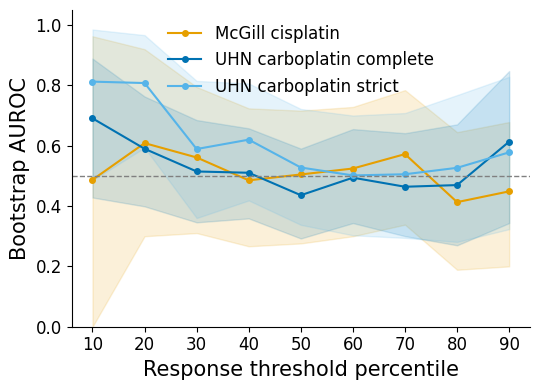

In [9]:
fig, ax = plt.subplots(figsize=(5.5, 4))

for name, sweep in sweep_results.items():
    color = COHORT_PLOT_COLORS[name]
    ax.plot(sweep["percentile"], sweep["auroc"], color=color, marker="o", markersize=4,
            label=name.replace("_", " "))
    ax.fill_between(sweep["percentile"], sweep["ci_lo"], sweep["ci_hi"], color=color, alpha=0.15)

ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Response threshold percentile", fontsize=15)
ax.set_ylabel("Bootstrap AUROC", fontsize=15)
ax.set_ylim(0, 1.05)
ax.set_xticks(PERCENTILES)
ax.tick_params(axis="both", labelsize=12)
ax.legend(frameon=False, fontsize=12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
out_path = FIGURES_DIR / "figure4e_auroc_percentile_sweep.png"
plt.savefig(out_path, dpi=300)
plt.savefig(out_path.with_suffix(".pdf"))
print("Saved:", out_path)
plt.show()

### Effect of the response-window cap: capped (10-28 day) vs. uncapped (full duration)

The 10-28 day response window was chosen from the data's own confound structure (window-choice
justification cells in `3-cohort_comparison.ipynb`: McGill's median treatment-arm slope bottoms out
at max.time=28 and erodes at wider windows; the uncensored slope is confounded with follow-up duration
in both cohorts), independent of downstream model performance. Having made that choice on those
grounds, we report its effect on AUROC here as a consequence, not as the basis for the choice --
comparing the current capped label against an uncapped (min.time=10, max.time=NULL) alternative, using
the already-computed uncapped slope.treatment values from `window_confound_sweep.R`.

In [10]:
UNCAPPED_FILE = {
    "McGill_cisplatin": "McGill_slope_full_duration.csv",
    "UHN_carboplatin_complete": "UHN_slope_full_duration.csv",
    "UHN_carboplatin_strict": "UHN_slope_full_duration.csv",
}

uncapped_auroc_results = {}
print("AUROC: predicted response vs. sensitive (slope.treatment < 0) -- capped vs. uncapped")
for name, df in predictions.items():
    uncapped = pd.read_csv(paths["proc"] / UNCAPPED_FILE[name]).rename(
        columns={"slope.treatment": "slope.treatment_uncapped"}
    )
    merged = df.merge(uncapped, on="batch.name", how="left")
    sub = merged.dropna(subset=["average", "slope.treatment_uncapped"])
    target = (sub["slope.treatment_uncapped"] < 0).astype(int)

    point, lo, hi, boot_aucs = bootstrap_auroc(target, sub["average"])
    uncapped_auroc_results[name] = {
        "auroc": point, "ci_lo": lo, "ci_hi": hi, "n": len(sub),
        "n_sensitive": int(target.sum()), "boot_aucs": boot_aucs,
    }

    r_c = auroc_results[name]
    print(f"  {name}:")
    print(f"    capped   (10-28 day): AUROC={r_c['auroc']:.3f} [{r_c['ci_lo']:.3f}-{r_c['ci_hi']:.3f}] "
          f"(sensitive={r_c['n_sensitive']}/{r_c['n']})")
    print(f"    uncapped (full dur.): AUROC={point:.3f} [{lo:.3f}-{hi:.3f}] "
          f"(sensitive={target.sum()}/{len(sub)})")
    print(f"    delta (capped - uncapped): {r_c['auroc'] - point:+.3f}")

AUROC: predicted response vs. sensitive (slope.treatment < 0) -- capped vs. uncapped


  McGill_cisplatin:
    capped   (10-28 day): AUROC=0.486 [0.260-0.697] (sensitive=16/29)
    uncapped (full dur.): AUROC=0.457 [0.231-0.678] (sensitive=15/29)
    delta (capped - uncapped): +0.028


  UHN_carboplatin_complete:
    capped   (10-28 day): AUROC=0.577 [0.371-0.771] (sensitive=12/68)
    uncapped (full dur.): AUROC=0.587 [0.414-0.755] (sensitive=16/68)
    delta (capped - uncapped): -0.009


  UHN_carboplatin_strict:
    capped   (10-28 day): AUROC=0.839 [0.626-0.984] (sensitive=5/36)
    uncapped (full dur.): AUROC=0.762 [0.550-0.950] (sensitive=10/36)
    delta (capped - uncapped): +0.077


In [11]:
# Same capped-vs-uncapped comparison printed above (Figure 4d), saved as a table.
capped_vs_uncapped_rows = []
for name in predictions:
    r_c = auroc_results[name]
    r_u = uncapped_auroc_results[name]
    capped_vs_uncapped_rows.append({
        "Cohort": name.replace("_", " "),
        "AUROC_capped": r_c["auroc"], "AUROC_capped_ci_lo": r_c["ci_lo"], "AUROC_capped_ci_hi": r_c["ci_hi"],
        "n_sensitive_capped": r_c["n_sensitive"], "n_capped": r_c["n"],
        "AUROC_uncapped": r_u["auroc"], "AUROC_uncapped_ci_lo": r_u["ci_lo"], "AUROC_uncapped_ci_hi": r_u["ci_hi"],
        "n_sensitive_uncapped": r_u["n_sensitive"], "n_uncapped": r_u["n"],
        "delta_capped_minus_uncapped": r_c["auroc"] - r_u["auroc"],
    })
capped_vs_uncapped = pd.DataFrame(capped_vs_uncapped_rows)
capped_vs_uncapped_file = TABLES_DIR / "table6_case3_capped_vs_uncapped_auroc.csv"
capped_vs_uncapped.to_csv(capped_vs_uncapped_file, index=False)
print(f"Saved: {capped_vs_uncapped_file}")
capped_vs_uncapped

Saved: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/figures_tables/tables/table6_case3_capped_vs_uncapped_auroc.csv


,Cohort,AUROC_capped,AUROC_capped_ci_lo,AUROC_capped_ci_hi,n_sensitive_capped,n_capped,AUROC_uncapped,AUROC_uncapped_ci_lo,AUROC_uncapped_ci_hi,n_sensitive_uncapped,n_uncapped,delta_capped_minus_uncapped
0,McGill cisplatin,0.485577,0.259572,0.696973,16,29,0.457143,0.230760,0.677780,15,29,0.028434
1,UHN carboplatin complete,0.577381,0.370968,0.771093,12,68,0.586538,0.414304,0.754719,16,68,-0.009158
2,UHN carboplatin strict,0.838710,0.626042,0.984375,5,36,0.761538,0.549980,0.949508,10,36,0.077171


Saved: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/figures_tables/figures_main/figure4d_capped_vs_uncapped_auroc.png


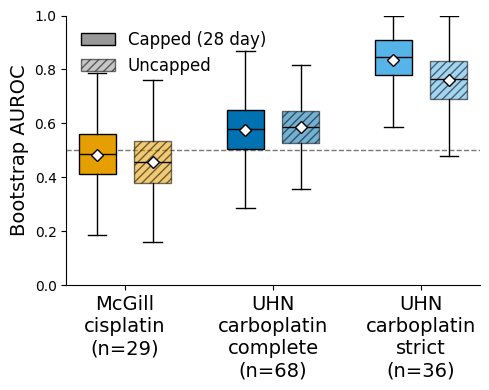

In [12]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(5, 4))

names = list(predictions.keys())
ax.axhline(0.5, color="#777777", linestyle="--", linewidth=1, zorder=1)

positions, box_data, colors, hatches = [], [], [], []
for i, name in enumerate(names):
    positions += [i * 2.4, i * 2.4 + 0.9]
    box_data += [auroc_results[name]["boot_aucs"], uncapped_auroc_results[name]["boot_aucs"]]
    colors += [COHORT_PLOT_COLORS[name], COHORT_PLOT_COLORS[name]]
    hatches += [None, "////"]

bp = ax.boxplot(
    box_data, positions=positions, widths=0.6,
    showfliers=False, showmeans=True, patch_artist=True,
    medianprops=dict(color="black"),
    meanprops=dict(marker="D", markerfacecolor="white", markeredgecolor="black", markersize=6),
    whiskerprops=dict(color="black"), capprops=dict(color="black"), boxprops=dict(color="black"),
)
for patch, color, hatch in zip(bp["boxes"], colors, hatches):
    patch.set_facecolor(color)
    patch.set_alpha(0.55 if hatch else 1.0)
    if hatch:
        patch.set_hatch(hatch)

ax.set_xticks([i * 2.4 + 0.45 for i in range(len(names))])
ax.set_xticklabels(
    [nm.replace("_", "\n") + f"\n(n={auroc_results[nm]['n']})" for nm in names], fontsize=14
)
ax.set_ylabel("Bootstrap AUROC", fontsize=14)
ax.set_ylim(0, 1)

legend_handles = [
    Patch(facecolor="0.6", edgecolor="black", label="Capped (28 day)"),
    Patch(facecolor="0.6", edgecolor="black", hatch="////", alpha=0.55, label="Uncapped"),
]
ax.legend(handles=legend_handles, frameon=False, loc="upper left", fontsize=12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
out_path = FIGURES_DIR / "figure4d_capped_vs_uncapped_auroc.png"
plt.savefig(out_path, dpi=300)
plt.savefig(out_path.with_suffix(".pdf"))
print("Saved:", out_path)
plt.show()